# OIBSIP Data Analytics — Task 1 (Level 1): EDA on Retail Sales Data
**Track:** Data Analytics | **Task:** EDA on Retail Sales Data | **Level:** 1

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `retail_sales_data.csv` — 6,000 retail orders (2022–2023) across 5 product categories, 4 regions, with customer age/gender and per-order revenue.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

df = pd.read_csv('retail_sales_data.csv', parse_dates=['OrderDate'])
df.shape


(6000, 12)

## 1. Initial Inspection

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   OrderID         6000 non-null   str           
 1   OrderDate       6000 non-null   datetime64[us]
 2   CustomerID      6000 non-null   str           
 3   CustomerAge     5985 non-null   float64       
 4   CustomerGender  6000 non-null   str           
 5   ProductID       6000 non-null   str           
 6   ProductName     6000 non-null   str           
 7   Category        6000 non-null   str           
 8   Quantity        6000 non-null   int64         
 9   UnitPrice       6000 non-null   float64       
 10  Revenue         6000 non-null   float64       
 11  Region          6000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(7)
memory usage: 562.6 KB


In [3]:
df.isnull().sum()


OrderID            0
OrderDate          0
CustomerID         0
CustomerAge       15
CustomerGender     0
ProductID          0
ProductName        0
Category           0
Quantity           0
UnitPrice          0
Revenue            0
Region             0
dtype: int64

**Observation:** The dataset has 12 columns and 6,000 rows spanning Jan 2022–Dec 2023. Only `CustomerAge` has a small number of nulls (15 rows) — negligible relative to dataset size.

## 2. Descriptive Statistics (Numerical Columns)

In [4]:
df[['CustomerAge','Quantity','UnitPrice','Revenue']].describe()


,CustomerAge,Quantity,UnitPrice,Revenue
count,5985.000000,6000.000000,6000.000000,6000.000000
mean,31.719131,1.279500,1680.282570,2160.147410
std,8.578834,0.512273,1006.658582,1677.285167
min,16.000000,1.000000,152.760000,155.890000
25%,26.000000,1.000000,920.652500,1043.857500
50%,32.000000,1.000000,1452.970000,1722.585000
75%,38.000000,1.000000,2202.037500,2763.042500
max,60.000000,3.000000,4498.430000,13489.470000


In [5]:
print('Mode of CustomerAge:', df['CustomerAge'].mode()[0])
print('Mode of Quantity:', df['Quantity'].mode()[0])
print('Mode of Category:', df['Category'].mode()[0])
print('Mode of Region:', df['Region'].mode()[0])


Mode of CustomerAge: 32.0
Mode of Quantity: 1
Mode of Category: Electronics
Mode of Region: North


**Observation:** Average order revenue is a few thousand rupees, with most orders being for a single unit (`Quantity` mode = 1). Customer age is centred in the early-30s, consistent with a working-age online shopper base.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

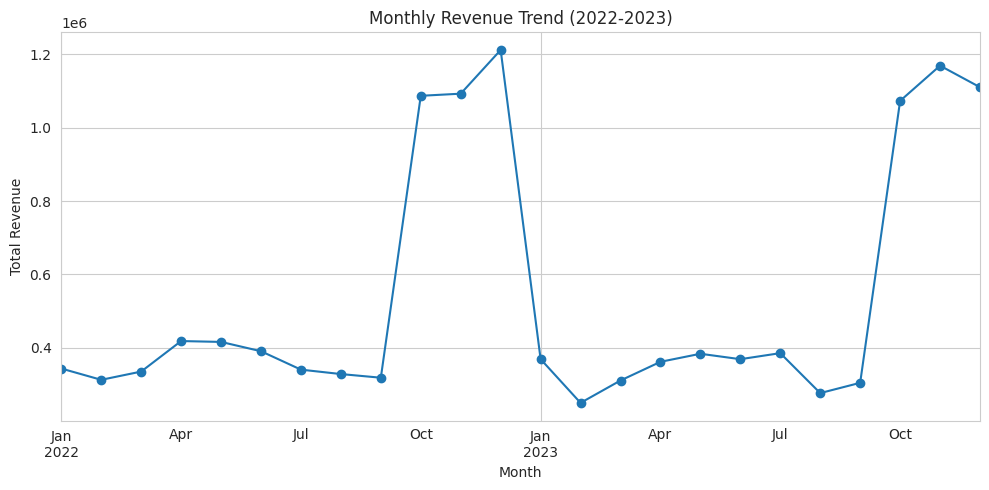

In [6]:
monthly = df.set_index('OrderDate').resample('ME')['Revenue'].sum()
plt.figure()
monthly.plot(marker='o')
plt.title('Monthly Revenue Trend (2022-2023)')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


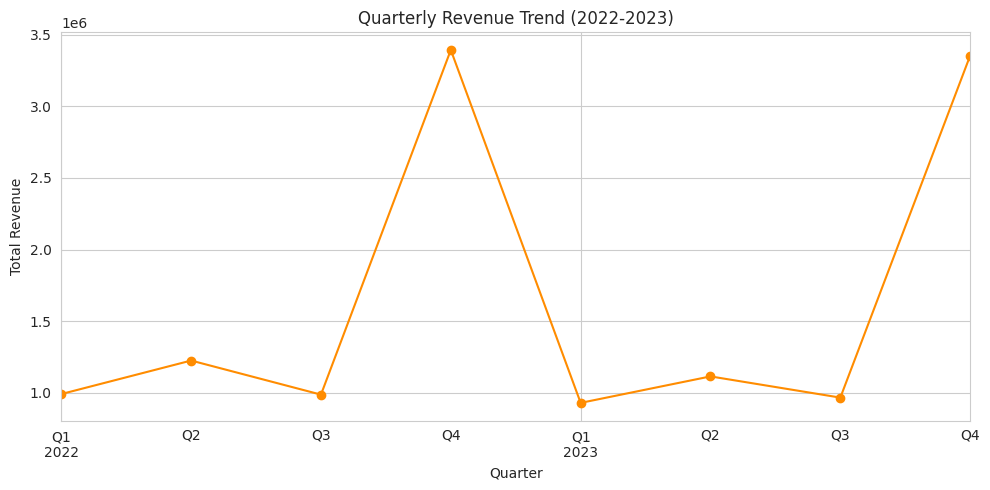

In [7]:
quarterly = df.set_index('OrderDate').resample('QE')['Revenue'].sum()
plt.figure()
quarterly.plot(marker='o', color='darkorange')
plt.title('Quarterly Revenue Trend (2022-2023)')
plt.ylabel('Total Revenue')
plt.xlabel('Quarter')
plt.tight_layout()
plt.show()


**Observation:** Revenue shows a clear seasonal spike in Q4 (October–December) of both years, consistent with festive/holiday shopping behaviour. This is the strongest recurring pattern in the data and should drive inventory and marketing timing decisions.

## 4. Customer Demographics Analysis

/tmp/ipykernel_558/3356408269.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AgeGroup', order=age_labels, palette='viridis')


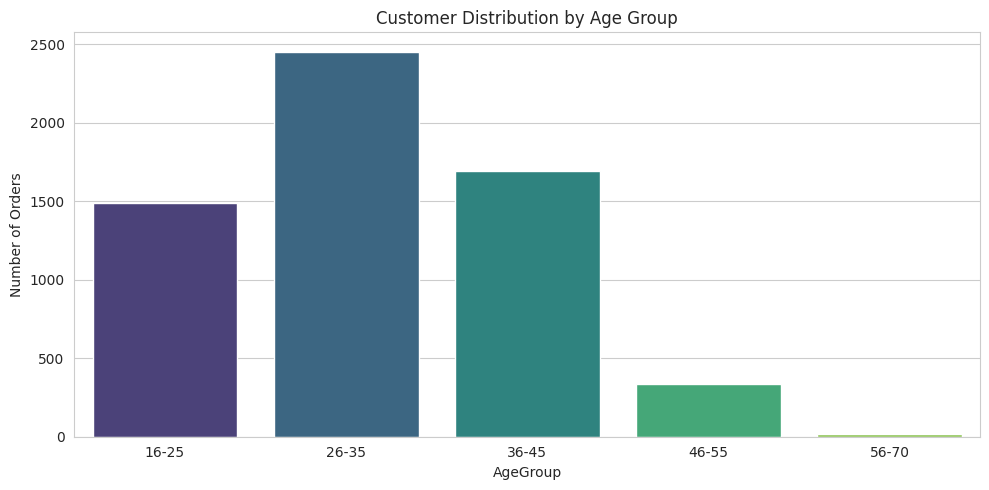

In [8]:
age_bins = [15,25,35,45,55,70]
age_labels = ['16-25','26-35','36-45','46-55','56-70']
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels)

plt.figure()
sns.countplot(data=df, x='AgeGroup', order=age_labels, palette='viridis')
plt.title('Customer Distribution by Age Group')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


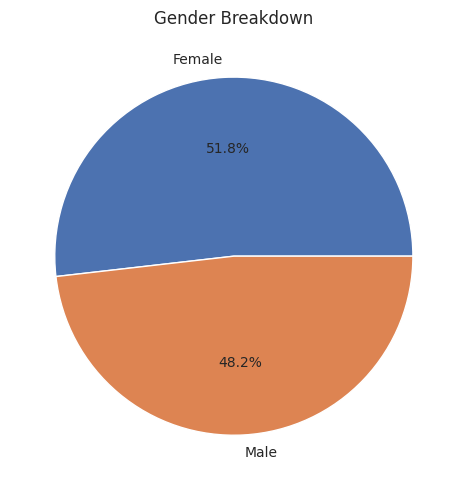

In [9]:
plt.figure(figsize=(5,5))
df['CustomerGender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.title('Gender Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Observation:** The 26–35 age group is the single largest contributor to order volume, and the customer base is fairly gender-balanced with a slight lean towards female shoppers (~52%).

## 5. Product Analysis

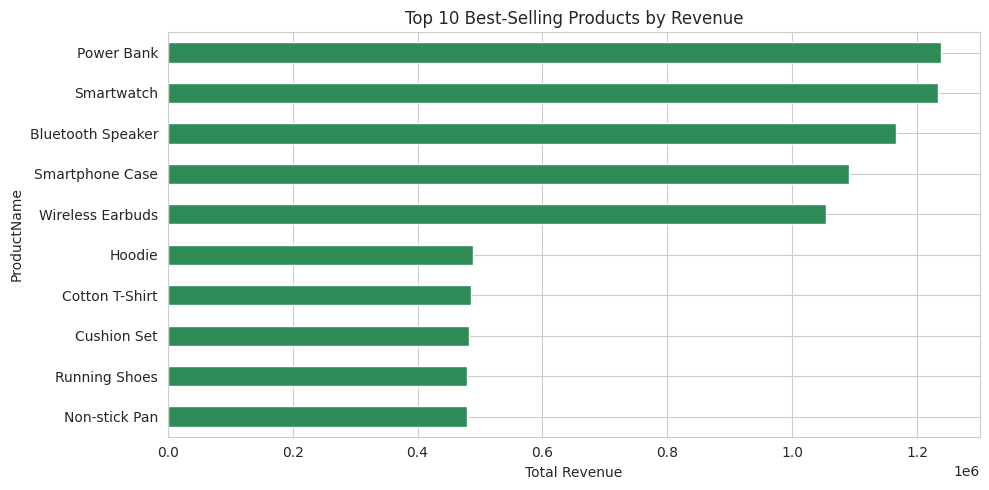

ProductName
Power Bank           1238950.40
Smartwatch           1233752.76
Bluetooth Speaker    1166319.10
Smartphone Case      1090755.82
Wireless Earbuds     1054227.77
Hoodie                489293.31
Cotton T-Shirt        484961.71
Cushion Set           482848.89
Running Shoes         479700.85
Non-stick Pan         479110.59
Name: Revenue, dtype: float64

In [10]:
top_products = df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind='barh', color='seagreen')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
top_products


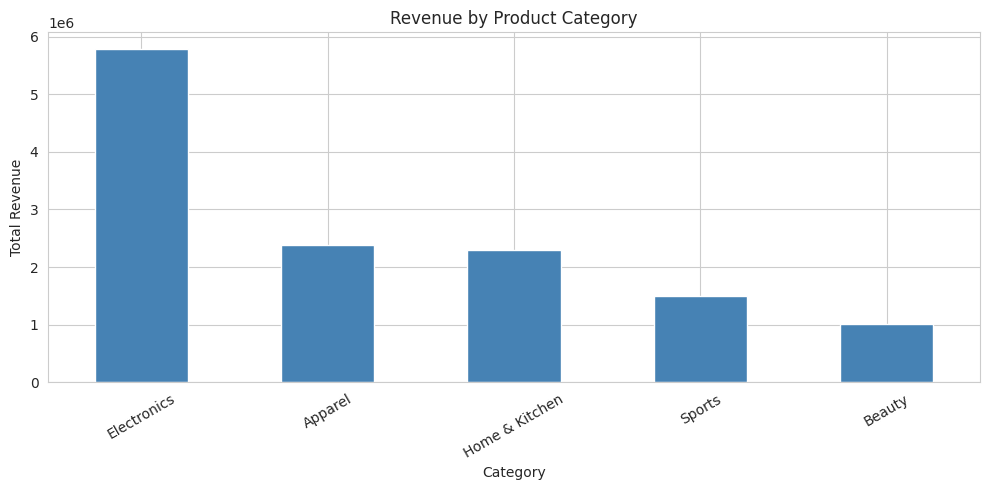

Category
Electronics       5784005.85
Apparel           2376527.33
Home & Kitchen    2304599.72
Sports            1490844.69
Beauty            1004906.87
Name: Revenue, dtype: float64

In [11]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
plt.figure()
category_revenue.plot(kind='bar', color='steelblue')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
category_revenue


**Observation:** Electronics generates the highest total revenue despite not having the most orders — its higher unit price per item drives outsized revenue contribution relative to categories like Beauty, which sells more units at a lower price point.

## 6. Correlation Heatmap

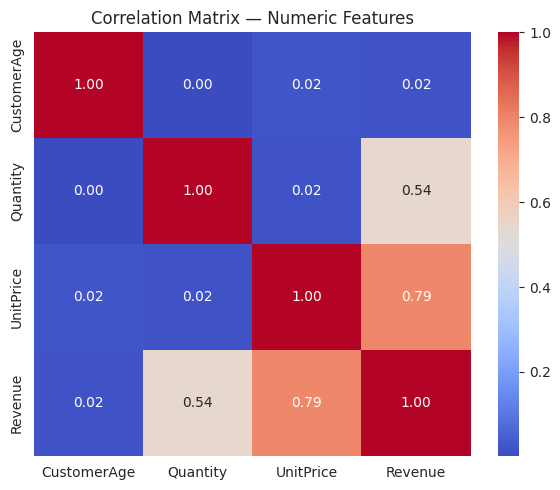

In [12]:
numeric_cols = ['CustomerAge','Quantity','UnitPrice','Revenue']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


**Observation:** `UnitPrice` and `Revenue` are strongly correlated (as expected, since Revenue = UnitPrice × Quantity), while `CustomerAge` shows negligible correlation with spend — age alone is not a strong predictor of order value in this dataset.

## 7. Additional Insight — Regional Performance by Category

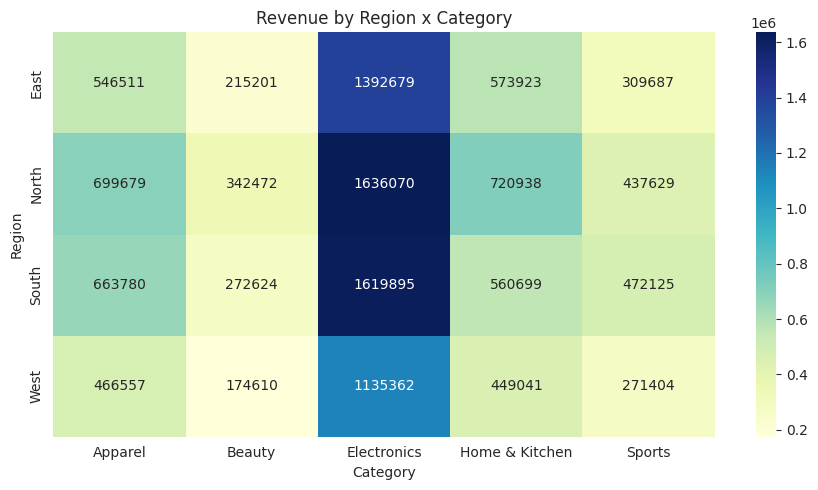

Category,Apparel,Beauty,Electronics,Home & Kitchen,Sports
Region,,,,,
East,546511.11,215201.04,1392679.39,573922.70,309686.84
North,699679.01,342471.55,1636070.32,720937.53,437628.83
South,663779.79,272624.28,1619894.53,560698.67,472124.73
West,466557.42,174610.00,1135361.61,449040.82,271404.29


In [13]:
region_cat = df.pivot_table(index='Region', columns='Category', values='Revenue', aggfunc='sum')
plt.figure(figsize=(9,5))
sns.heatmap(region_cat, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Revenue by Region x Category')
plt.tight_layout()
plt.show()
region_cat


**Observation (non-obvious insight):** While the North region leads in overall revenue, its lead is driven almost entirely by Electronics — in Apparel and Sports, the South region actually outperforms it. A region-wide strategy would miss this category-level nuance.

## 8. Conclusion — Actionable Business Recommendations

Based on the analysis above:

1. **Front-load inventory and marketing spend into Q4.** Revenue consistently spikes in October–December across both years — stock levels and ad budgets should scale up ahead of this window rather than reactively.
2. **Double down on Electronics in the North region, but tailor category mix by region.** The North leads on Electronics specifically, while South leads in Apparel/Sports — a one-size-fits-all regional campaign under-serves these category-specific strengths.
3. **Target the 26–35 age segment with tailored campaigns**, since it is the largest order-volume group, while testing outreach strategies to grow share among the currently smaller 46+ segments.
